
# 🌳 Arbres de desició - Regressió
Aquest notebook mostrem com funciona el model d'arbres de desició en l'àmbit de regressió o també anomentats **Arbres de regressió**
Notebook inspirat en *StatQuest* de *Josh Stramer*

---

## 🎯 Objectius
- Entendre com es va construïnt l'arbre de desició

## 💊 Exemple - Eficàcia d'un medicament

Tenim un conjunt de dades d'entrenament que consistesn en l'**eficàcia** d'un medicament respecte la **dosis** que s'administra als pacients.

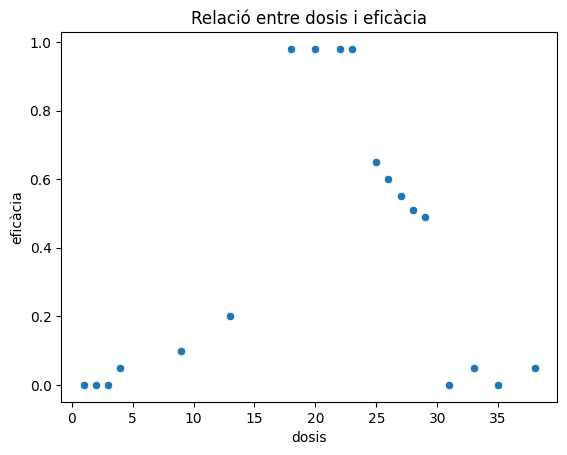

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dosis_g1 = [1,2,3,4,9,13]
dosis_g2 = [18,20,22,23]
dosis_g3 = [25,26,27,28,29]
dosis_g4 = [31,33,35,38]
dosis = dosis_g1 + dosis_g2 + dosis_g3 + dosis_g4


eficacia_g1 = [0,0,0,0.05,0.10,0.20]
eficacia_g2 = [0.98,0.98,0.98,0.98]
eficacia_g3 = [0.65,0.60,0.55,0.51,0.49]
eficacia_g4 = [0,0.05,0,0.05]
eficacia = eficacia_g1 + eficacia_g2 + eficacia_g3 + eficacia_g4

#

#print(np.mean(eficacia_g1))
#0.058
#0.980
#0.559
#0.025


dades = {
    'dosis': dosis,
    'eficacia': eficacia
}

df = pd.DataFrame(dades)

# Scatter plot bàsic
sns.scatterplot(data=df, x="dosis", y="eficacia")
plt.title("Relació entre dosis i eficàcia")
plt.xlabel("dosis")
plt.ylabel("eficàcia")
plt.show()

Si creem un arbre per cada subgrup podriem tenir el següent arbre de desició

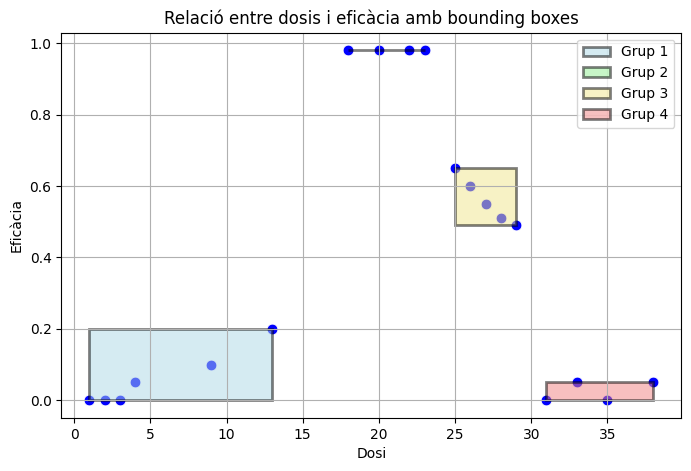

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

# Dades
dosis     = dosis_g1 + dosis_g2 + dosis_g3 + dosis_g4
eficacia  = eficacia_g1 + eficacia_g2 + eficacia_g3 + eficacia_g4

df = pd.DataFrame({
    'dosis': dosis,
    'eficacia': eficacia
})


# Definim subgrups de dosis per dibuixar bounding boxes
subgrups = [
    (1, 13, 'lightblue', 'Grup 1'),
    (18, 23, 'lightgreen', 'Grup 2'),
    (25, 29, 'khaki', 'Grup 3'),
    (31, 38, 'lightcoral', 'Grup 4')
]

# Scatter plot base
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='dosis', y='eficacia', s=60, color='blue')

# Afegim bounding boxes
ax = plt.gca()
for xmin, xmax, color, label in subgrups:
    subset = df[(df['dosis'] >= xmin) & (df['dosis'] <= xmax)]
    if subset.empty:
        continue
    ymin, ymax = subset['eficacia'].min(), subset['eficacia'].max()

    rect = patches.Rectangle(
        (xmin, ymin),               # (x, y) de la cantonada inferior esquerra
        xmax - xmin,                # amplada
        ymax - ymin,                # alçada
        linewidth=2,
        edgecolor='black',
        facecolor=color,
        alpha=0.5,
        label=label
    )
    ax.add_patch(rect)

plt.title("Relació entre dosis i eficàcia amb bounding boxes")
plt.xlabel("Dosi")
plt.ylabel("Eficàcia")
plt.legend()
plt.grid(True)
plt.show()


Arbre de desició amb els subgrups que veiem.


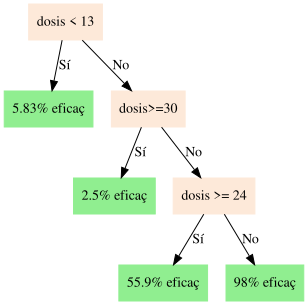

In [ ]:
from graphviz import Digraph

# Crear objecte de Graphviz
dot = Digraph()

# Nivell 1 (arrel)
dot.node('A', 'dosis < 13', shape="box",style='filled', color='#FDE9D9')

# Nivell 2
dot.node('B', '5.83% eficaç', shape='box', style='filled', color='lightgreen')
dot.node('C', 'dosis>=30', shape='box', style='filled', color='#FDE9D9')

# Connexions de l’arrel
dot.edge('A', 'B', label='Sí')
dot.edge('A', 'C', label='No')

# Nivell 3 (fills de C)
dot.node('D', '2.5% eficaç', shape='box', style='filled', color='lightgreen')
dot.node('E', 'dosis >= 24', shape='box', style='filled', color='#FDE9D9')

# Connexions del node E
dot.edge('C', 'D', label='Sí')
dot.edge('C', 'E', label='No')

# Nivell 4 (fills de E)
dot.node('F', '55.9% eficaç', shape='box', style='filled', color='lightgreen')
dot.node('G', '98% eficaç', shape='box', style='filled', color='lightgreen')

# Connexions del node E
dot.edge('E', 'F', label='Sí')
dot.edge('E', 'G', label='No')

# Mostrar l’arbre dins Colab
dot.render('arbre_decisio', format='png', view=False)
dot


## Com construïm l'arbre? Quin valor posarem a l'arrel

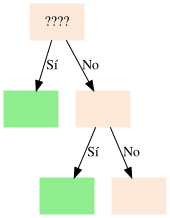

In [ ]:
# Crear objecte de Graphviz
dot = Digraph()

# Nivell 1 (arrel)
dot.node('A', '????', shape="box",style='filled', color='#FDE9D9')

# Nivell 2
dot.node('B', '    ', shape='box', style='filled', color='lightgreen')
dot.node('C', '    ', shape='box', style='filled', color='#FDE9D9')

# Connexions de l’arrel
dot.edge('A', 'B', label='Sí')
dot.edge('A', 'C', label='No')

# Nivell 3 (fills de C)
dot.node('D', '    ', shape='box', style='filled', color='lightgreen')
dot.node('E', '', shape='box', style='filled', color='#FDE9D9')

# Connexions del node E
dot.edge('C', 'D', label='Sí')
dot.edge('C', 'E', label='No')

# Mostrar l’arbre dins Colab
dot.render('arbre_decisio', format='png', view=False)
dot

--- Resultats per x_ref = 4 ---
Mitjana esquerra (x ≤ 4): 0.013
Mitjana dreta (x > 4): 0.475
SSR esquerra: 0.002
SSR dreta: 2.102
SSR total: 2.104



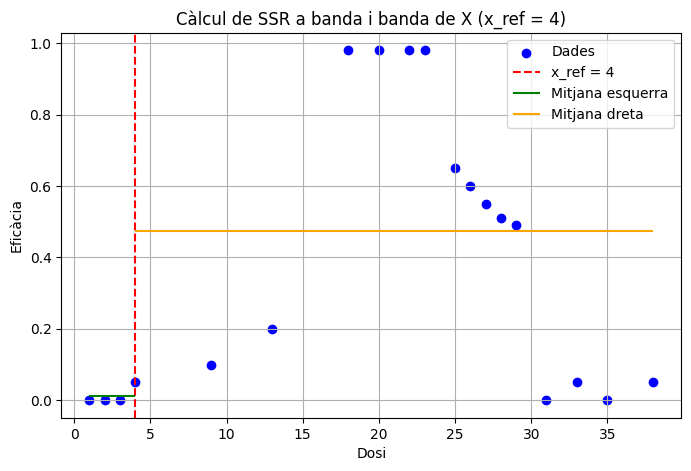

np.float64(2.104048333333334)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calcula_ssr_i_grafic(dosis, eficacia, x_ref):
    """
    Calcula SSR esquerra i dreta a partir d'un punt x_ref,
    mostra els valors per consola i genera el gràfic corresponent.
    Retorna SSR_total.
    """

    # Crear màscares
    mask_left = dosis <= x_ref
    mask_right = dosis > x_ref

    # Comprovar que hi ha dades a banda i banda
    if np.sum(mask_left) == 0 :
        print(f"x_ref={x_ref} costat esquerra buit — ajusta el valor.")
        return np.nan
    if np.sum(mask_right) == 0:
        mask_left = dosis < x_ref
        mask_right = dosis >= x_ref
        print(f"x_ref={x_ref} costat dret buit — ajusta el valor.")
        #return np.nan

    # Dividir dades
    x_left, y_left = dosis[mask_left], eficacia[mask_left]
    x_right, y_right = dosis[mask_right], eficacia[mask_right]

    # Mitjanes
    mitjana_left = np.mean(y_left)
    mitjana_right = np.mean(y_right)

    # SSR per cada costat
    SSR_left = np.sum((y_left - mitjana_left) ** 2)
    SSR_right = np.sum((y_right - mitjana_right) ** 2)
    SSR_total = SSR_left + SSR_right

    # Prints de resultats
    print(f"--- Resultats per x_ref = {x_ref} ---")
    print(f"Mitjana esquerra (x ≤ {x_ref}): {mitjana_left:.3f}")
    print(f"Mitjana dreta (x > {x_ref}): {mitjana_right:.3f}")
    print(f"SSR esquerra: {SSR_left:.3f}")
    print(f"SSR dreta: {SSR_right:.3f}")
    print(f"SSR total: {SSR_total:.3f}\n")

    # Visualització
    plt.figure(figsize=(8,5))
    plt.scatter(dosis, eficacia, label='Dades', color='blue')
    plt.axvline(x=x_ref, color='red', linestyle='--', label=f'x_ref = {x_ref}')

    # Línies horitzontals amb les mitjanes
    plt.hlines(mitjana_left, dosis.min(), x_ref, color='green', linestyle='-', label='Mitjana esquerra')
    plt.hlines(mitjana_right, x_ref, dosis.max(), color='orange', linestyle='-', label='Mitjana dreta')

    plt.title(f'Càlcul de SSR a banda i banda de X (x_ref = {x_ref})')
    plt.xlabel('Dosi')
    plt.ylabel('Eficàcia')
    plt.legend()
    plt.grid(True)
    plt.show()

    return SSR_total


calcula_ssr_i_grafic(df['dosis'],df['eficacia'], 4)

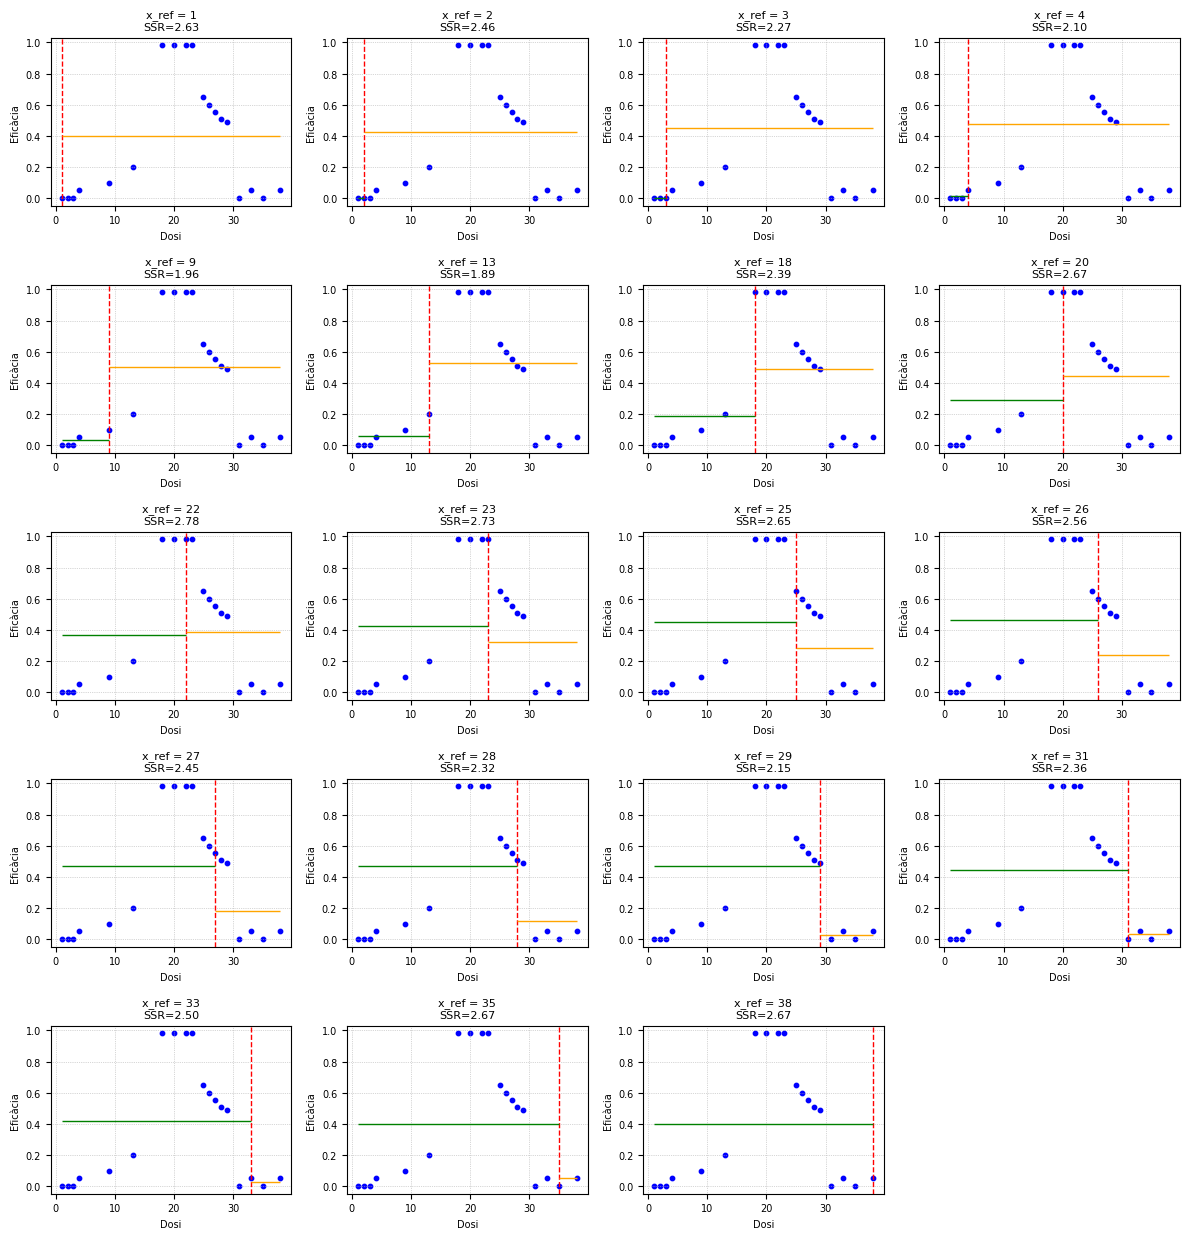

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

def calcula_ssr_i_grafic(dosis, eficacia, x_ref, ax=None):
    """
    Calcula SSR esquerra i dreta per un punt x_ref.
    Si es passa un eix (ax), dibuixa dins d'aquest subplot.
    Retorna SSR_total.
    """

    # Crear màscares
    mask_left = dosis <= x_ref
    mask_right = dosis > x_ref


    # Comprovar que hi ha dades a banda i banda
    if np.sum(mask_left) == 0 :
        print(f"x_ref={x_ref} costat esquerra buit — ajusta el valor.")
        return np.nan
    if np.sum(mask_right) == 0:
        mask_left = dosis < x_ref
        mask_right = dosis >= x_ref
        #return np.nan

    # Dividir dades
    x_left, y_left = dosis[mask_left], eficacia[mask_left]
    x_right, y_right = dosis[mask_right], eficacia[mask_right]

    # Mitjanes
    mitjana_left = np.mean(y_left)
    mitjana_right = np.mean(y_right)

    # SSR per cada costat
    SSR_left = np.sum((y_left - mitjana_left) ** 2)
    SSR_right = np.sum((y_right - mitjana_right) ** 2)
    SSR_total = SSR_left + SSR_right

    # Prints
    #No mostro els prints perquè ja mostro els gràfics.
    #print(f"--- x_ref = {x_ref} ---")
    #print(f"SSR esquerra: {SSR_left:.3f} | SSR dreta: {SSR_right:.3f} | Total: {SSR_total:.3f}")

    # Gràfic
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))

    ax.scatter(dosis, eficacia, color='blue', s=10)
    ax.axvline(x=x_ref, color='red', linestyle='--', lw=1)
    ax.hlines(mitjana_left, dosis.min(), x_ref, color='green', linestyle='-', lw=1)
    ax.hlines(mitjana_right, x_ref, dosis.max(), color='orange', linestyle='-', lw=1)

    ax.set_title(f"x_ref = {x_ref}\nSSR={SSR_total:.2f}", fontsize=8)
    ax.set_xlabel("Dosi", fontsize=7)
    ax.set_ylabel("Eficàcia", fontsize=7)
    ax.tick_params(axis='both', labelsize=7)
    ax.grid(True, linestyle=':', linewidth=0.5)

    return SSR_total


# ============================
# Executar per llista de valors
# ============================

# Exemple de dades (pots substituir pel teu df)
dosis = df['dosis']
eficacia = df['eficacia']

valors_x = [1, 2, 3, 4, 9, 13, 18, 20, 22, 23, 25, 26, 27, 28, 29, 31, 33, 35, 38]
n = len(valors_x)

# Crear graella de subplots petita i automàtica
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*2.5))
axes = axes.flatten()

ssr_totals = []

for i, x_ref in enumerate(valors_x):
    ssr_total = calcula_ssr_i_grafic(dosis, eficacia, x_ref, ax=axes[i])
    ssr_totals.append(ssr_total)

# Eliminar subplots buits (si n’hi ha)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


x_ref = 1 → SSR_total = 2.628
x_ref = 2 → SSR_total = 2.460
x_ref = 3 → SSR_total = 2.271
x_ref = 4 → SSR_total = 2.104
x_ref = 9 → SSR_total = 1.960
x_ref = 13 → SSR_total = 1.886
x_ref = 18 → SSR_total = 2.389
x_ref = 20 → SSR_total = 2.670
x_ref = 22 → SSR_total = 2.776
x_ref = 23 → SSR_total = 2.727
x_ref = 25 → SSR_total = 2.651
x_ref = 26 → SSR_total = 2.556
x_ref = 27 → SSR_total = 2.448
x_ref = 28 → SSR_total = 2.322
x_ref = 29 → SSR_total = 2.149
x_ref = 31 → SSR_total = 2.357
x_ref = 33 → SSR_total = 2.501
x_ref = 35 → SSR_total = 2.665
dosis amb SSR Min = 13


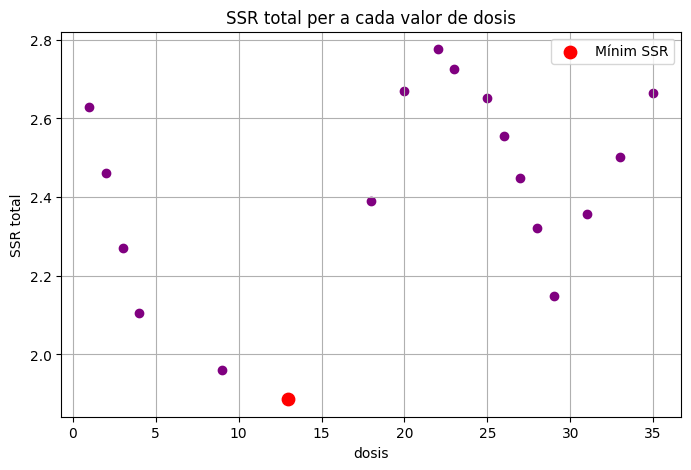

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Exemple de dades
dosis = df['dosis']
eficacia = df['eficacia']

#
# Punt X de tall
x_refs = [1,2,3,4,9,13] + [18,20,22,23] + [25,26,27,28,29] + [31,33,35,38]

# Llistes per guardar resultats
ssr_totals = []

for x_ref in x_refs:


    # Màscares per cada costat
    mask_left = dosis <= x_ref
    mask_right = dosis > x_ref

    # Evitar casos buits
    if np.sum(mask_left) == 0 or np.sum(mask_right) == 0:
        ssr_totals.append(np.nan)
        continue

    # Mitjanes
    mitjana_left = np.mean(eficacia[mask_left])
    mitjana_right = np.mean(eficacia[mask_right])

    # SSRs
    SSR_left = np.sum((eficacia[mask_left] - mitjana_left) ** 2)
    SSR_right = np.sum((eficacia[mask_right] - mitjana_right) ** 2)
    SSR_total = SSR_left + SSR_right

    ssr_totals.append(SSR_total)

    print(f"x_ref = {x_ref} → SSR_total = {SSR_total:.3f}")

# Crear un array de resultats
x_refs = np.array(x_refs)
ssr_totals = np.array(ssr_totals)


# Gràfic principal de SSR_total vs x_ref
plt.figure(figsize=(8,5))
plt.scatter(x_refs, ssr_totals, color='purple')
plt.title('SSR total per a cada valor de dosis')
plt.xlabel('dosis')
plt.ylabel('SSR total')
plt.grid(True)

# Destaquem el punt mínim
if not np.all(np.isnan(ssr_totals)):
    idx_min = np.nanargmin(ssr_totals)
    plt.scatter(x_refs[idx_min], ssr_totals[idx_min], color='red', s=80, label='Mínim SSR')

    print(f"dosis amb SSR Min = {x_refs[idx_min]}")
    plt.legend()

plt.show()



Ara tenim que el punt de tall amb una dosi=13.
Tenim 5 mesures al node de l'esquerra i, en teroia podriem subdividir aquestes mesures en grups més petits repetint el que acabem de fer, però aquesta vegada només amb aqeust subconjunt de 5 valors.

Si fem aixó acabarem les fulles amb un únic punt i això sobre ajudtarà les dades d'entrenemant.

Per tant, la manera més fàcil de no fer sobreajustament és que hi hagi un número mínim de fulles. Normalment aquest número és 20. D'aquí venen els paràmetre `min_samples_leaf` (Nombre mínim de mostres per fulla) i `min_samplet_split` (Nombre mínim de mostres per dividir un node)


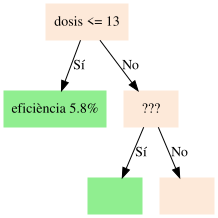

In [ ]:
# Crear objecte de Graphviz
dot = Digraph()

# Nivell 1 (arrel)
dot.node('A', 'dosis <= 13', shape="box",style='filled', color='#FDE9D9')

# Nivell 2
dot.node('B', 'eficiència 5.8%', shape='box', style='filled', color='lightgreen')
dot.node('C', '???', shape='box', style='filled', color='#FDE9D9')

# Connexions de l’arrel
dot.edge('A', 'B', label='Sí')
dot.edge('A', 'C', label='No')

# Nivell 3 (fills de C)
dot.node('D', '    ', shape='box', style='filled', color='lightgreen')
dot.node('E', '', shape='box', style='filled', color='#FDE9D9')

# Connexions del node E
dot.edge('C', 'D', label='Sí')
dot.edge('C', 'E', label='No')

# Mostrar l’arbre dins Colab
dot.render('arbre_decisio', format='png', view=False)
dot

x_ref = 18 → SSR_total = 2.389
x_ref = 20 → SSR_total = 2.670
x_ref = 22 → SSR_total = 2.776
x_ref = 23 → SSR_total = 2.727
x_ref = 25 → SSR_total = 2.651
x_ref = 26 → SSR_total = 2.556
x_ref = 27 → SSR_total = 2.448
x_ref = 28 → SSR_total = 2.322
x_ref = 29 → SSR_total = 2.149
x_ref = 31 → SSR_total = 2.357
x_ref = 33 → SSR_total = 2.501
x_ref = 35 → SSR_total = 2.665
dosis amb SSR Min = 29


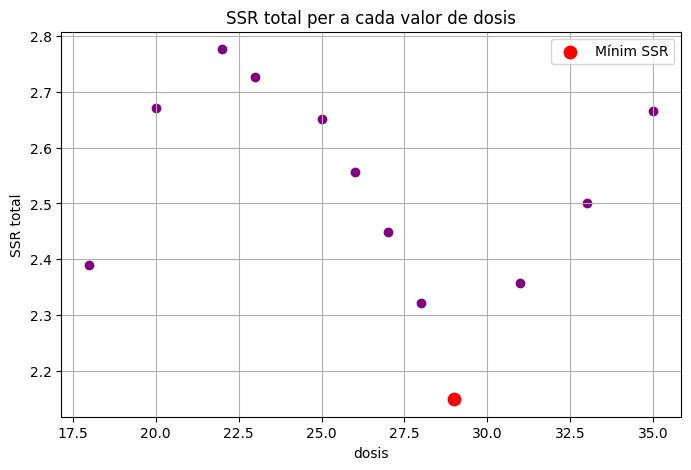

In [ ]:
# Dades
dosis     = dosis_g1 + dosis_g2 + dosis_g3 + dosis_g4
eficacia  = eficacia_g1 + eficacia_g2 + eficacia_g3 + eficacia_g4

df = pd.DataFrame({
    'dosis': dosis,
    'eficacia': eficacia
})


import numpy as np
import matplotlib.pyplot as plt

# Exemple de dades
dosis = df['dosis']
eficacia = df['eficacia']

#
# Punt X de tall
x_refs = [18,20,22,23] + [25,26,27,28,29] + [31,33,35,38]

# Llistes per guardar resultats
ssr_totals = []

for x_ref in x_refs:


    # Màscares per cada costat
    mask_left = dosis <= x_ref
    mask_right = dosis > x_ref

    # Evitar casos buits
    if np.sum(mask_left) == 0 or np.sum(mask_right) == 0:
        ssr_totals.append(np.nan)
        continue

    # Mitjanes
    mitjana_left = np.mean(eficacia[mask_left])
    mitjana_right = np.mean(eficacia[mask_right])

    # SSRs
    SSR_left = np.sum((eficacia[mask_left] - mitjana_left) ** 2)
    SSR_right = np.sum((eficacia[mask_right] - mitjana_right) ** 2)
    SSR_total = SSR_left + SSR_right

    ssr_totals.append(SSR_total)

    print(f"x_ref = {x_ref} → SSR_total = {SSR_total:.3f}")

# Crear un array de resultats
x_refs = np.array(x_refs)
ssr_totals = np.array(ssr_totals)


# Gràfic principal de SSR_total vs x_ref
plt.figure(figsize=(8,5))
plt.scatter(x_refs, ssr_totals, color='purple')
plt.title('SSR total per a cada valor de dosis')
plt.xlabel('dosis')
plt.ylabel('SSR total')
plt.grid(True)

# Destaquem el punt mínim
if not np.all(np.isnan(ssr_totals)):
    idx_min = np.nanargmin(ssr_totals)
    plt.scatter(x_refs[idx_min], ssr_totals[idx_min], color='red', s=80, label='Mínim SSR')

    print(f"dosis amb SSR Min = {x_refs[idx_min]}")
    plt.legend()

plt.show()


Ara veiem que el millor punt és el dosi=29

En aquest cas tenim 8 valors a l'esquerra i 3 valors a la dreta. Per tant ja tenim un altre node fulla.

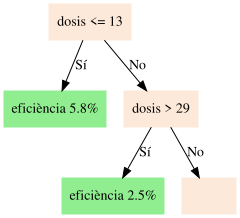

In [ ]:
# Crear objecte de Graphviz
dot = Digraph()

# Nivell 1 (arrel)
dot.node('A', 'dosis <= 13', shape="box",style='filled', color='#FDE9D9')

# Nivell 2
dot.node('B', 'eficiència 5.8%', shape='box', style='filled', color='lightgreen')
dot.node('C', 'dosis > 29', shape='box', style='filled', color='#FDE9D9')

# Connexions de l’arrel
dot.edge('A', 'B', label='Sí')
dot.edge('A', 'C', label='No')

# Nivell 3 (fills de C)
dot.node('D', 'eficiència 2.5%', shape='box', style='filled', color='lightgreen')
dot.node('E', '', shape='box', style='filled', color='#FDE9D9')

# Connexions del node E
dot.edge('C', 'D', label='Sí')
dot.edge('C', 'E', label='No')

# Mostrar l’arbre dins Colab
dot.render('arbre_decisio', format='png', view=False)
dot

## Exemple 0 - Dosisis - Eficàcia

R² (test): 0.948
RMSE (test): 0.06


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


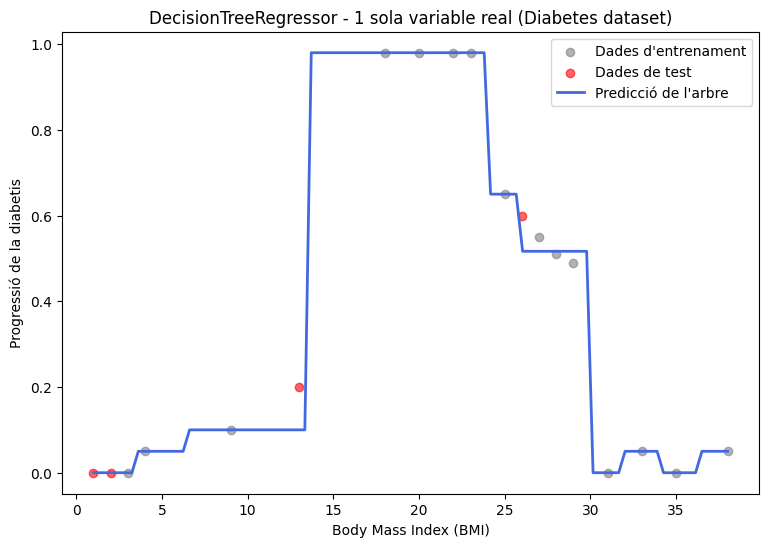

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error,root_mean_squared_error

# 1️⃣ Carreguem dades reals

dosis_g1 = [1,2,3,4,9,13]
dosis_g2 = [18,20,22,23]
dosis_g3 = [25,26,27,28,29]
dosis_g4 = [31,33,35,38]
dosis = dosis_g1 + dosis_g2 + dosis_g3 + dosis_g4


eficacia_g1 = [0,0,0,0.05,0.10,0.20]
eficacia_g2 = [0.98,0.98,0.98,0.98]
eficacia_g3 = [0.65,0.60,0.55,0.51,0.49]
eficacia_g4 = [0,0.05,0,0.05]
eficacia = eficacia_g1 + eficacia_g2 + eficacia_g3 + eficacia_g4

dades = {
    'dosis': dosis,
    'eficacia': eficacia
}

df = pd.DataFrame(dades)

# 2️⃣ Dividim entrenament/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df[['dosis']], df[['eficacia']], test_size=0.2, random_state=42
)

# 3️⃣ Creem el model
model = DecisionTreeRegressor(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# 4️⃣ Prediccions
y_pred = model.predict(X_test)

# 5️⃣ Mètriques
print(f"R² (test): {r2_score(y_test, y_pred):.3f}")
print(f"RMSE (test): {root_mean_squared_error(y_test, y_pred):.2f}")

# 6️⃣ Visualització
X_plot = np.linspace(df[['dosis']].min(), df[['dosis']].max(), 100).reshape(-1, 1)
y_plot = model.predict(X_plot)

plt.figure(figsize=(9, 6))
plt.scatter(X_train, y_train, color="gray", label="Dades d'entrenament", alpha=0.6)
plt.scatter(X_test, y_test, color="red", label="Dades de test", alpha=0.6)
plt.plot(X_plot, y_plot, color="royalblue", linewidth=2, label="Predicció de l'arbre")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Progressió de la diabetis")
plt.title("DecisionTreeRegressor - 1 sola variable real (Diabetes dataset)")
plt.legend()
plt.show()

## 🏠 Exemple 2 - Boston Housing

Volem predir la variable MEDV. valor mijtà de les vivendes.

En el conjunt de dades tenim:
- **CRIM**: taxa de delinqüència per càpita per ciutat.
- **ZN**: proporció de sòl residencial dividit per a segments de més de 25.000 peus quadrats.
- **INDUS**: proporció de superfície comercial no minorista per ciutat.
- **CHAS**: variable binària sobre el riu Charles (= 1 si la zona limita amb el riu; 0 en cas contrari).
- **NOX**: concentració d'òxids nítrics (parts de 10 milions).
- **RM**: nombre mitjà d'habitacions per habitatge.
- **EDAT**: proporció d'habitatges ocupats construïts abans del 1940.
- **DIS**: distància ponderada a cinc centres de treball a la ciutat de Boston.
- **RAD**: índex daccessibilitat a les autopistes radials.
- **TAX**: impost sobre béns immobles de valor íntegre per cada 10.000 dólars
- **PTRATIO**: ràtio alumnes-professor per ciutat.
- **LSTAT**: % de la població considerat de classe baixa.
- **MEDV** (variable a predir): valor mitjà dels habitatges en milers de $.

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name boston exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=531
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=853

  warn(warning_msg)
/tmp/ipython-input-1914677916.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette="viridis")


Train: 379 observacions
Test: 127 observacions
R² (test): 0.556
RMSE (test): 5.921


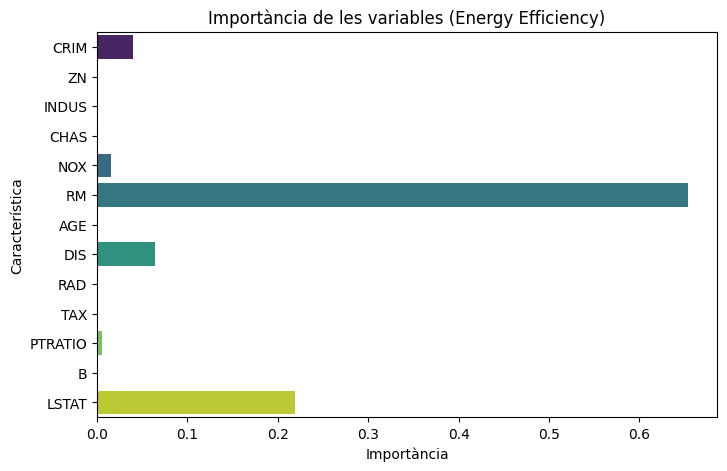

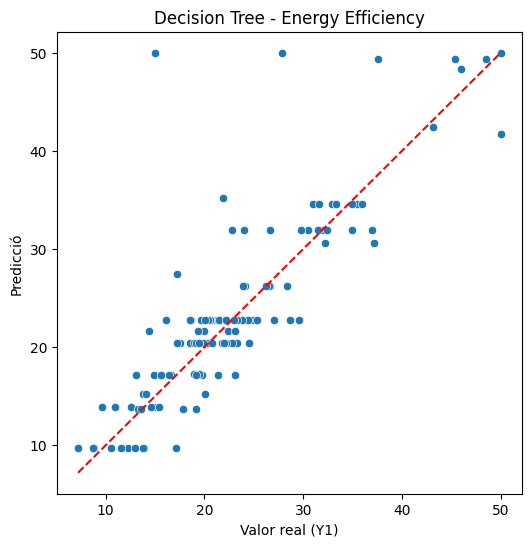

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error,root_mean_squared_error
from sklearn.datasets import fetch_openml

# 1️⃣ Load the Boston Housing dataset
boston = fetch_openml(name='boston')

df = boston['data']
df['MEDV'] = boston['target']
df.head()

# 2️⃣ Definim variables
X = df.drop(columns="MEDV")
y = df['MEDV']

# 3️⃣ Split train/test
# Dividim el conjunt de dades train/test
X_train, X_test, y_train, y_test = train_test_split(
                                        df.drop(columns="MEDV"),
                                        df['MEDV'],
                                        test_size = 0.25,
                                        random_state = 123
                                    )

print(f"Train: {X_train.shape[0]} observacions")
print(f"Test: {X_test.shape[0]} observacions")

# 4️⃣ Model
model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 5️⃣ Prediccions
y_pred = model.predict(X_test)

# 6️⃣ Mètriques
print(f"R² (test): {r2_score(y_test, y_pred):.3f}")
print(f"RMSE (test): {root_mean_squared_error(y_test, y_pred):.3f}")

# 7️⃣ Importància de característiques
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Importància de les variables (Energy Efficiency)")
plt.xlabel("Importància")
plt.ylabel("Característica")
plt.show()

# 8️⃣ Relació predicció vs valors reals
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valor real (Y1)")
plt.ylabel("Predicció")
plt.title("Decision Tree - Energy Efficiency")
plt.show()


## Exercici - Millor el model anterior

Utilitzant el `GridSearchCV` de Scikit-learn intenta millorar el model anterior.
